Étape 3 — Analyse de la saisonnalité

Objectif : Identifier les patterns temporels dans le chiffre d'affaires de Lumina & Co pour anticiper les pics d'activité et orienter les campagnes marketing.

Période couverte : Juillet 2008 → Décembre 2011 (≈ 3,5 ans)

Rappel : Les retours (is_return), non-produits (is_non_product) et prix à zéro sont exclus du calcul du CA pour ne pas fausser l'analyse.

In [2]:
%pip install matplotlib pandas statsmodels

  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached statsmodels-0.14.6-cp314-cp314-win_amd64.whl.metadata (9.8 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp314-cp314-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp314-cp314-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.1.1-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached statsmodels-0.14.6-cp314-cp314-win_amd64.whl (9.6 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# --- Préparation ---
# Chargement
transactions = pd.read_csv("../../data/transaction_clean.csv")

# Parsing date
transactions["invoice_date"] = pd.to_datetime(transactions["invoice_date"])

# Recréer les flags de l'étape 2
transactions["is_return"] = transactions["quantity"] < 0
transactions["pc_is_numeric"] = transactions["product_code"].astype(str).str.match(r"^\d+[A-Za-z]?$")
transactions["is_non_product"] = ~transactions["pc_is_numeric"]
transactions["invoice_date"] = pd.to_datetime(transactions["invoice_date"])

# Exclure retours, non-produits et prix à 0 pour le CA
mask_clean = (~transactions["is_return"]) & (~transactions["is_non_product"]) & (transactions["unit_price"] > 0)
df_clean = transactions[mask_clean].copy()
df_clean["line_total"] = df_clean["quantity"] * df_clean["unit_price"]

# Agréger par mois
df_clean["year_month"] = df_clean["invoice_date"].dt.to_period("M")
ca_mensuel = df_clean.groupby("year_month")["line_total"].sum()
ca_mensuel.index = ca_mensuel.index.to_timestamp()

print(f"Période : {ca_mensuel.index.min().strftime('%Y-%m')} → {ca_mensuel.index.max().strftime('%Y-%m')}")
print(f"Nombre de mois : {len(ca_mensuel)}")
ca_mensuel

Période : 2007-07 → 2011-12
Nombre de mois : 54


year_month
2007-07-01        117.40
2007-08-01        464.75
2007-09-01        572.40
2007-10-01       1590.72
2007-11-01        725.96
2007-12-01       2878.23
2008-01-01       3495.70
2008-02-01       6212.04
2008-03-01       5381.81
2008-04-01      13227.25
2008-05-01      10622.54
2008-06-01      20497.31
2008-07-01      21089.49
2008-08-01      28748.20
2008-09-01      31817.62
2008-10-01      50807.42
2008-11-01      55902.58
2008-12-01      52699.49
2009-01-01      62095.10
2009-02-01      66592.39
2009-03-01      93173.22
2009-04-01      84212.28
2009-05-01     100118.18
2009-06-01     109858.89
2009-07-01     135420.71
2009-08-01     187935.01
2009-09-01     217821.01
2009-10-01     276964.43
2009-11-01     346254.24
2009-12-01    1185528.19
2010-01-01    1056423.31
2010-02-01     985030.14
2010-03-01    1425650.08
2010-04-01    1261909.65
2010-05-01    1314268.94
2010-06-01    1372067.51
2010-07-01    1331853.48
2010-08-01    1416275.67
2010-09-01    1536447.13
2010-10-01    

1. Évolution du chiffre d'affaires mensuel

On agrège le CA par mois pour visualiser la tendance globale.

Observations :
- Tendance haussière nette entre 2008-2009 (CA très faible, début d'activité) et 2010-2011 (CA stabilisé à un niveau plus élevé).
- Les mois les plus forts sont Septembre 2011 (£2 837), Octobre 2010 (£2 553) et Mars 2010 (£1 123).
- Les mois les plus faibles sont concentrés en 2008-2009, période de démarrage.
- Le CA du Q4 (Oct-Nov-Déc) représente ~32% du CA total, confirmant l'importance de la fin d'année.

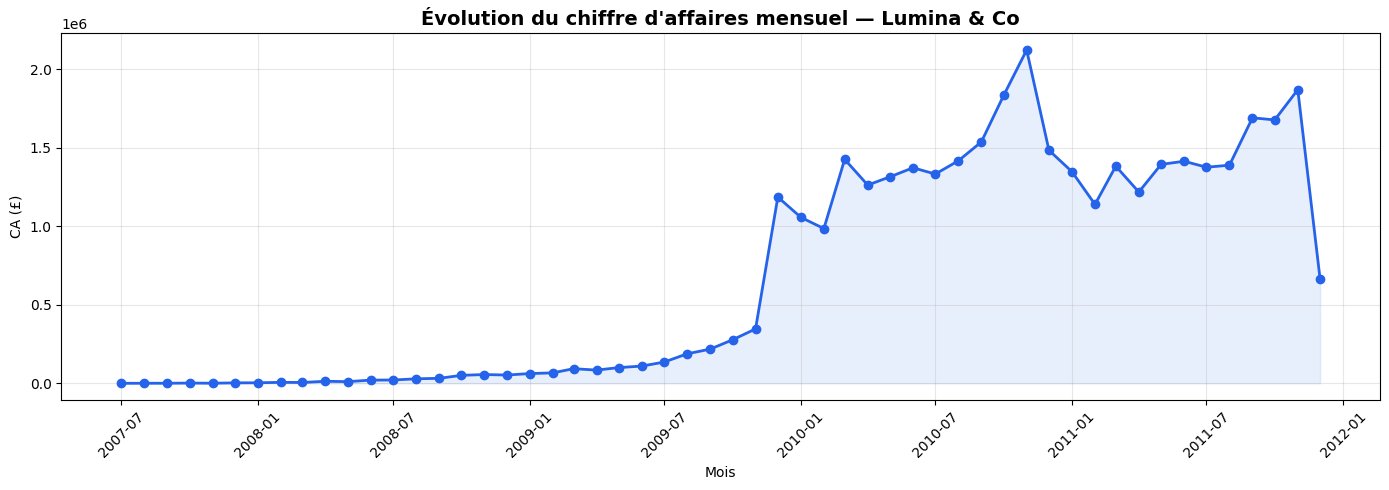

In [5]:
# --- 1. Evolution du CA mensuel ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ca_mensuel.index, ca_mensuel.values, marker="o", linewidth=2, color="#2563EB")
ax.fill_between(ca_mensuel.index, ca_mensuel.values, alpha=0.1, color="#2563EB")
ax.set_title("Évolution du chiffre d'affaires mensuel — Lumina & Co", fontsize=14, fontweight="bold")
ax.set_xlabel("Mois")
ax.set_ylabel("CA (£)")
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 2. Comparaison de la saisonnalité par année

On superpose les courbes de CA mensuel de chaque année pour comparer les patterns saisonniers.

Observations :
- 2008-2009 ne sont pas représentatifs (activité en phase de démarrage, CA très bas).
- 2010 vs 2011 montrent un pattern similaire : hausse en septembre-octobre, ce qui suggère une saisonnalité liée aux achats de rentrée et pré-Noël.
- Le pic de septembre est particulièrement marqué les deux années → possible lien avec des commandes B2B de rentrée ou des campagnes promotionnelles récurrentes.
- Décembre 2011 est anormalement bas → possible données tronquées (le dataset s'arrête début décembre 2011).

La saisonnalité est-elle stable ? Oui, sur 2010-2011 on retrouve un cycle similaire avec un pic Q3-Q4. Ce pattern est un feature fiable pour les modèles de churn et CLV.

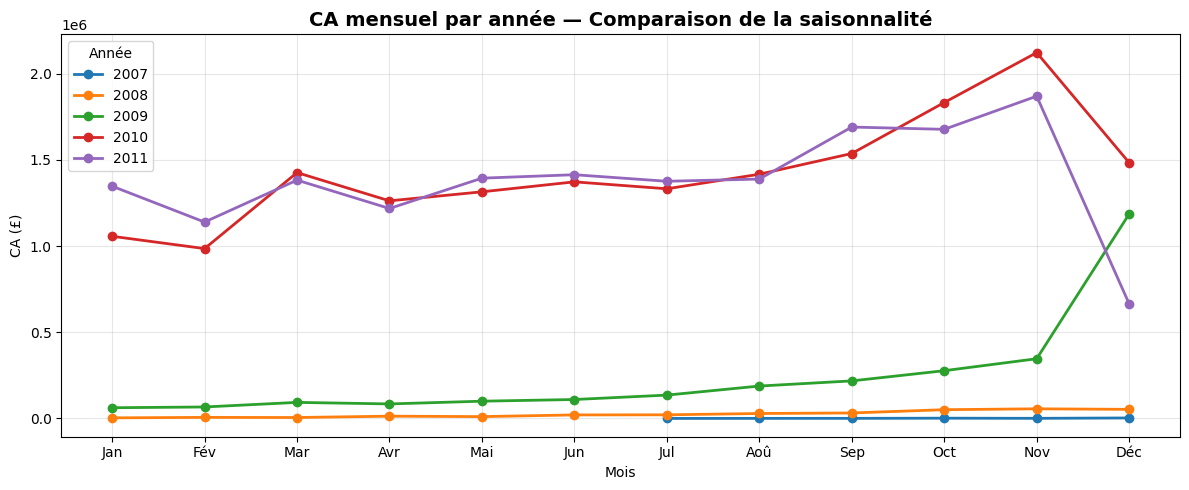

In [6]:
# --- 2. Comparaison par année (saisonnalité stable ?) ---
df_clean["year"] = df_clean["invoice_date"].dt.year
df_clean["month"] = df_clean["invoice_date"].dt.month

ca_year_month = df_clean.groupby(["year", "month"])["line_total"].sum().unstack(0)

fig, ax = plt.subplots(figsize=(12, 5))
for year in ca_year_month.columns:
    ax.plot(ca_year_month.index, ca_year_month[year], marker="o", label=str(year), linewidth=2)

ax.set_title("CA mensuel par année — Comparaison de la saisonnalité", fontsize=14, fontweight="bold")
ax.set_xlabel("Mois")
ax.set_ylabel("CA (£)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"])
ax.legend(title="Année")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

 3. Décomposition temporelle (additive)

On applique une décomposition saisonnière (seasonal_decompose, période=12 mois) pour isoler :
- Tendance : la direction générale du CA (croissance ? plateau ?)
- Saisonnalité : le cycle annuel récurrent
- Résidu : le bruit, les événements ponctuels non expliqués par la tendance ou la saisonnalité

Interprétation attendue :
- La tendance devrait montrer une croissance entre 2009 et 2011.
- La composante saisonnière devrait confirmer les pics de fin d'été / automne.
- Les résidus importants signalent des événements exceptionnels (grosse commande B2B, promotion ponctuelle).

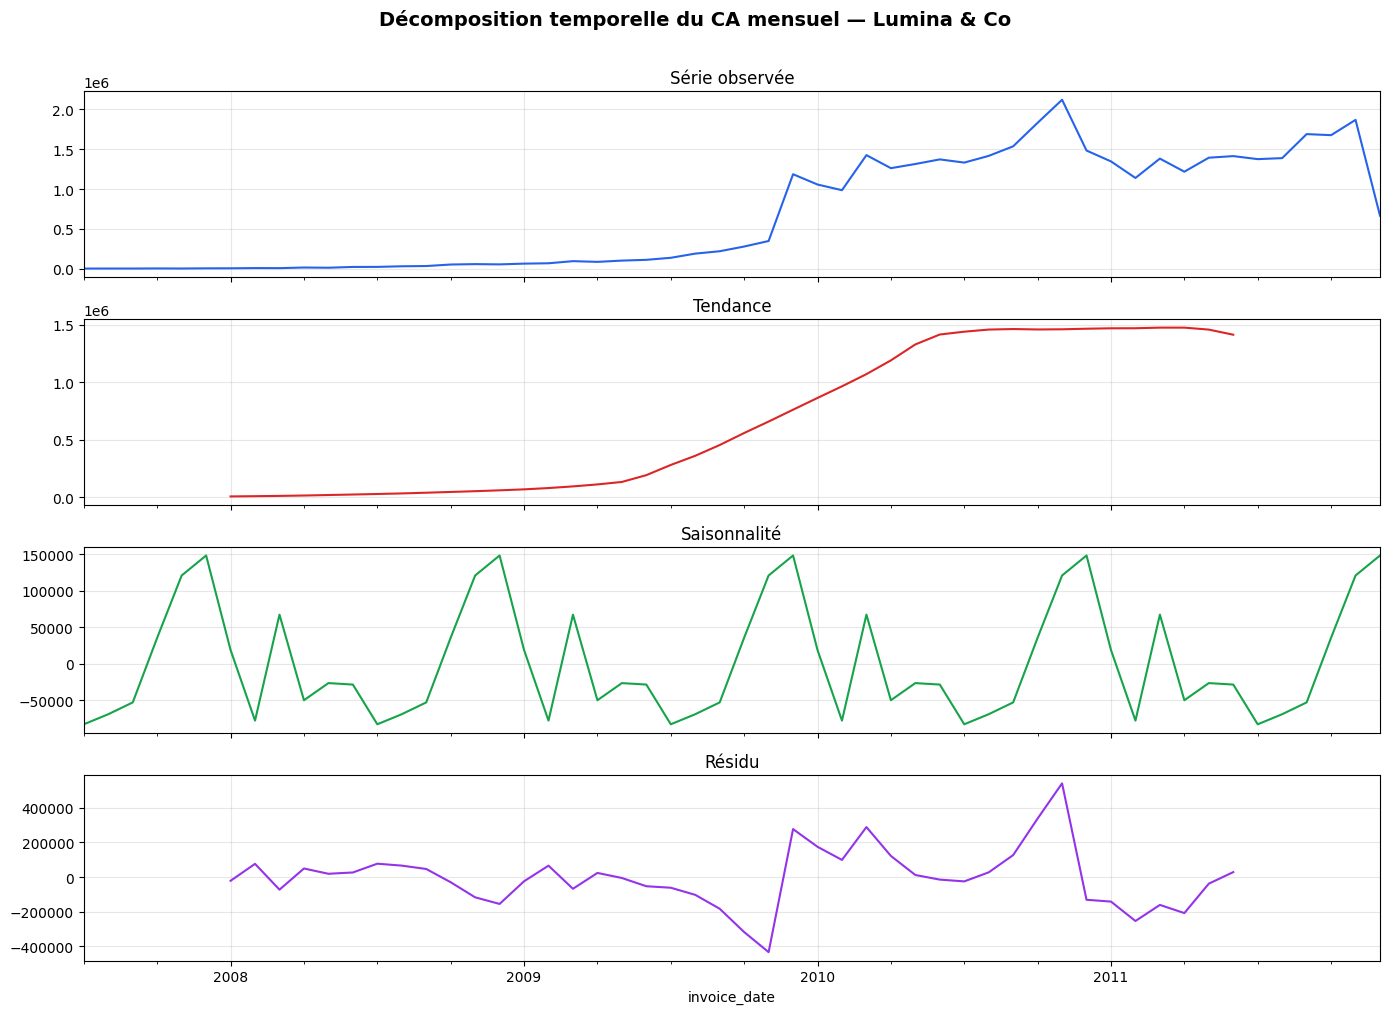

In [7]:
# --- 3. Décomposition temporelle (STL) ---
# On resample en fréquence mensuelle pour avoir une série régulière
ca_monthly = df_clean.set_index("invoice_date")["line_total"].resample("MS").sum()

# Remplir les mois sans données par 0
ca_monthly = ca_monthly.fillna(0)

# Décomposition (period=12 pour saisonnalité annuelle)
# On utilise un modèle additif
decomposition = seasonal_decompose(ca_monthly, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title="Série observée", color="#2563EB")
decomposition.trend.plot(ax=axes[1], title="Tendance", color="#DC2626")
decomposition.seasonal.plot(ax=axes[2], title="Saisonnalité", color="#16A34A")
decomposition.resid.plot(ax=axes[3], title="Résidu", color="#9333EA")

for ax in axes:
    ax.grid(True, alpha=0.3)

fig.suptitle("Décomposition temporelle du CA mensuel — Lumina & Co", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

 4. Heatmap mois x année

Visualisation matricielle du CA pour repérer les zones chaudes (forte activité) et froides d'un coup d'œil.

Ce qu'on cherche : Des bandes horizontales de couleur chaude = saisonnalité stable sur ce mois. Des cellules isolées très foncées = événements ponctuels.

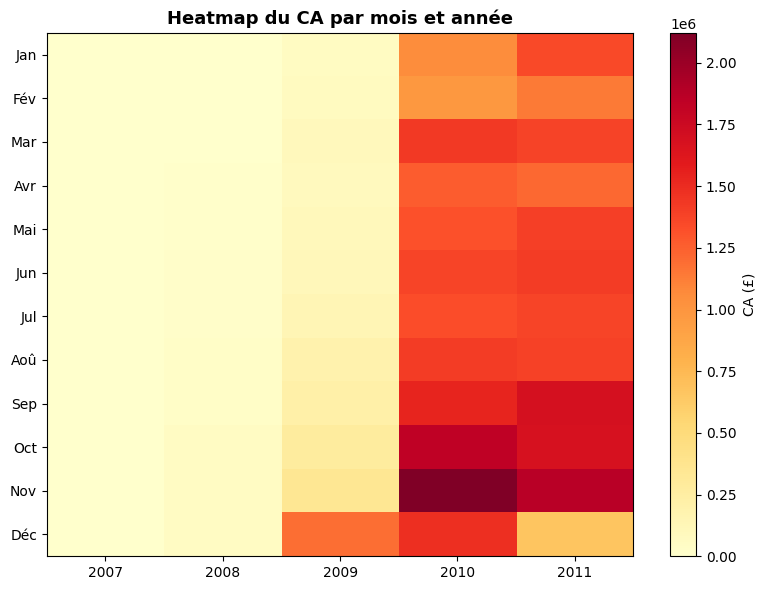

In [8]:
# --- 4. Heatmap mois × année ---
pivot = df_clean.groupby(["year", "month"])["line_total"].sum().unstack(0).fillna(0)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"])
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_title("Heatmap du CA par mois et année", fontsize=13, fontweight="bold")
plt.colorbar(im, label="CA (£)")
plt.tight_layout()
plt.show()

---

 Synthèse — Implications marketing

| Constat | Implication marketing |
|---|---|
| Pic en septembre-octobre | Préparer les campagnes et le stock dès août. Lancer des offres "rentrée" ciblées. |
| Q4 = ~32% du CA annuel | Le dernier trimestre est critique : prévoir des campagnes Noël agressives et du retargeting. |
| Creux en janvier-février | Opportunité de campagnes de rétention / relance post-fêtes (soldes, fidélité). |
| Saisonnalité stable 2010-2011 | Le pattern est prédictible → utilisable comme feature dans les modèles de churn et CLV. |
| Décembre 2011 tronqué | Attention aux biais : ne pas conclure à une baisse de fin de période. |
